# 复现 walkthrough — `active_supContrast_iter20_visUnlabelData.ipynb`

本 notebook 逐步执行复现流程，并**保留每一步的中间结果**：数据形状、标签分布、
数据切分、模型结构、20 轮主动学习的逐轮指标、指标曲线，以及 UMAP / 标签传播 /
时序标签等可视化。

代码复用 `reproduce/` 下的模块（`data_preprocessing` / `model` / `train_eval`
/ `visualize`），与 `run_reproduce.py` 完全一致。

## 0. 环境与随机种子

In [1]:
import os, sys, random, pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

HERE = os.path.abspath('.')
sys.path.insert(0, HERE)

from data_preprocessing import (load_data, build_splits, data_loader_umineko,
                                majority_value, labeldict_findstr, label_colors,
                                labeldict_wounknown_findstr)
from model import SimpleNN, SupContrastiveLoss
from train_eval import (train_model, evaluate_model, evaluate_supContrast_model,
                        freeze_encoders, unfreeze_encoders, unfreeze_all,
                        uncertainty_sampling, AE_eval_time_series)

def set_random_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed); torch.cuda.manual_seed_all(seed)

SEED = 2025
set_random_seed(SEED)
device = 'cpu'
print('torch', torch.__version__, '| device', device, '| seed', SEED)

torch 2.8.0 | device cpu | seed 2025


## 1. 数据读取与预处理

加载 `all_norm_data.pkl`，对每个窗口的逐帧标签做多数投票，foraging(5)→-2(unknown)。

In [2]:
PKL = os.path.normpath(os.path.join(HERE, '..', 'analysis', 'pape_results', 'all_norm_data.pkl'))
data_b, label_b, vote_label = load_data(PKL)
print('data_b :', data_b.shape, data_b.dtype, '  (N, channels=3accel+1press, win_len=50)')
print('label_b:', label_b.shape, '  (per-timestep labels)')
print('vote_label:', vote_label.shape)

data_b : (168092, 4, 50) float64   (N, channels=3accel+1press, win_len=50)
label_b: (168092, 50)   (per-timestep labels)
vote_label: (168092,)


In [3]:
# 投票后标签分布
uniq, cnt = np.unique(vote_label, return_counts=True)
dist = pd.DataFrame({'label': uniq,
                     'name': [labeldict_findstr.get(int(u), str(u)) for u in uniq],
                     'count': cnt})
dist

,label,name,count
0,-2,unknown,160661
1,0,ground_stationary,1148
2,1,stationary,660
3,2,bathing,486
4,3,flying_active,4356
5,4,flying_passive,781


### 1.1 训练/测试切分 + labeled/unlabeled 切分

In [4]:
splits = build_splits(data_b, vote_label)
X_labeled, y_labeled   = splits['X_labeled'],   splits['y_labeled']
X_unlabeled, y_unlabeled = splits['X_unlabeled'], splits['y_unlabeled']
X_test, y_test         = splits['X_test'],      splits['y_test']
X_train_full           = splits['X_train_full']

print('X_labeled  :', X_labeled.shape)
print('X_unlabeled:', X_unlabeled.shape)
print('X_test     :', X_test.shape)

X_labeled  : (59, 4, 50)
X_unlabeled: (5885, 4, 50)
X_test     : (1487, 4, 50)


In [5]:
# 初始 labeled 集合的类别分布
u, c = np.unique(y_labeled, return_counts=True)
pd.DataFrame({'label': u, 'name': [labeldict_findstr[int(i)] for i in u], 'count': c})

,label,name,count
0,0,ground_stationary,10
1,1,stationary,5
2,3,flying_active,40
3,4,flying_passive,4


## 2. 模型

`SimpleNN`：3轴加速度走 `Autoencoder3d4`、1通道气压走 `Autoencoder1d`，各得 768 维特征，
拼接→1536→Linear 到 32 维共享嵌入；再分出 projector(对比学习16维) 与 classifier(5类)。

In [6]:
model = SimpleNN().to(device)
classify_criterion = nn.CrossEntropyLoss()
supContrast_criterion = SupContrastiveLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

n_params = sum(p.numel() for p in model.parameters())
print(f'总参数量: {n_params:,}')
print(model)

总参数量: 300,565
SimpleNN(
  (acc_encoder): Encoder3d4(
    (conv1): Conv1d(3, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv3): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (fc): Linear(in_features=768, out_features=64, bias=True)
  )
  (pre_encoder): Encoder1d(
    (conv1): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn1): BatchNorm1

In [7]:
# 单次前向，确认各阶段张量形状
model.eval()
with torch.no_grad():
    sample = torch.tensor(X_labeled[:4]).float()
    proj_out, feat32 = model(sample, if_contrast=True)
    clf_out, _       = model(sample, if_contrast=False)
print('共享32维特征 :', tuple(feat32.shape))
print('projector输出 :', tuple(proj_out.shape))
print('classifier输出:', tuple(clf_out.shape), '(softmax over 5类)')

共享32维特征 : (4, 32)
projector输出 : (4, 16)
classifier输出: (4, 5) (softmax over 5类)


## 3. 主动学习训练循环（20 轮）

每轮三阶段：①监督对比 warm-up（解冻编码器，10 epoch）②冻结编码器训练分类器（50 epoch）
③全解冻再训分类头（50 epoch）。随后在测试集评估，并用**熵不确定性采样**新增 1% 样本。

下方每轮都会打印训练/测试的 Accuracy、Macro-F1、Micro-F1（中间结果全部保留）。

In [8]:
set_random_seed(SEED)  # 重置以保证可复现
model = SimpleNN().to(device)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

max_iter, warmup, batch_size = 20, 20, 4000
update_size = max(int(0.01 * len(X_train_full)), 2)

metrics, loss_list, selected_labels_list = [], [], []
weight_list = []
iteration = 1
while len(X_unlabeled) > 0:
    print(f'============== Iteration {iteration} ==============')
    print(f'labeled={len(X_labeled)}  unlabeled={len(X_unlabeled)}')

    labeled_loader = DataLoader(
        data_loader_umineko(X_labeled.astype(float), y_labeled.astype(int)),
        batch_size=batch_size, shuffle=True, drop_last=False)

    # stage 1: supervised contrastive warm-up
    unfreeze_encoders(model)
    if iteration < warmup:
        model, _ = train_model(model, labeled_loader, supContrast_criterion,
                               optimizer, epochs=10, device=device, if_contrast=True)
    # stage 2: classifier-only
    freeze_encoders(model)
    model, _ = train_model(model, labeled_loader, classify_criterion,
                           optimizer, epochs=50, device=device, if_contrast=False)
    # stage 3: unfreeze all
    unfreeze_all(model)
    model, avg_loss = train_model(model, labeled_loader, classify_criterion,
                                  optimizer, epochs=50, device=device, if_contrast=False)
    loss_list.append(np.average(avg_loss))

    print('-- Train --')
    tr_acc, tr_macro, tr_micro, _, _ = evaluate_model(model, labeled_loader, device)
    test_loader = DataLoader(
        data_loader_umineko(X_test.astype(float), y_test.astype(int)),
        batch_size=batch_size, shuffle=False, drop_last=False)
    print('-- Test --')
    te_acc, te_macro, te_micro, _, _, _ = evaluate_supContrast_model(
        model, test_loader, cal_threshold=0.5, device=device)

    metrics.append(dict(iteration=iteration, labeled_samples=len(X_labeled),
                        train_acc=tr_acc, train_macro_f1=tr_macro, train_micro_f1=tr_micro,
                        test_acc=te_acc, test_macro_f1=te_macro, test_micro_f1=te_micro))
    weight_list.append({k: v.clone() for k, v in model.state_dict().items()})

    select_size = min(update_size, len(X_unlabeled))
    X_labeled, y_labeled, X_unlabeled, y_unlabeled, sel = uncertainty_sampling(
        X_labeled, y_labeled, X_unlabeled, y_unlabeled, model, select_size, device)
    selected_labels_list.append(sel)

    iteration += 1
    if iteration == max_iter + 1:
        break
print('训练循环完成')

============== Iteration 1 ==============
labeled=59  unlabeled=5885
-- Train --
Accuracy: 0.93, Macro F1 Score: 0.79, Micro F1 Score: 0.93
-- Test --
Accuracy: 0.78, Macro F1 Score: 0.44, Micro F1 Score: 0.78
Labeled samples: 118
============== Iteration 2 ==============
labeled=118  unlabeled=5826
-- Train --
Accuracy: 0.94, Macro F1 Score: 0.76, Micro F1 Score: 0.94
-- Test --
Accuracy: 0.83, Macro F1 Score: 0.59, Micro F1 Score: 0.83
Labeled samples: 177
============== Iteration 3 ==============
labeled=177  unlabeled=5767
-- Train --
Accuracy: 0.99, Macro F1 Score: 0.99, Micro F1 Score: 0.99
-- Test --
Accuracy: 0.84, Macro F1 Score: 0.70, Micro F1 Score: 0.84
Labeled samples: 236
============== Iteration 4 ==============
labeled=236  unlabeled=5708
-- Train --
Accuracy: 0.98, Macro F1 Score: 0.98, Micro F1 Score: 0.98
-- Test --
Accuracy: 0.87, Macro F1 Score: 0.73, Micro F1 Score: 0.87
Labeled samples: 295
============== Iteration 5 ==============
labeled=295  unlabeled=5649
-- 

## 4. 逐轮指标汇总

In [9]:
df = pd.DataFrame(metrics)
df

,iteration,labeled_samples,train_acc,train_macro_f1,train_micro_f1,test_acc,test_macro_f1,test_micro_f1
0,1,59,0.932203,0.791667,0.932203,0.784314,0.441263,0.784314
1,2,118,0.940678,0.760468,0.940678,0.828051,0.587041,0.828051
2,3,177,0.994350,0.990563,0.994350,0.843098,0.696761,0.843098
3,4,236,0.983051,0.976762,0.983051,0.866756,0.727147,0.866756
4,5,295,0.996610,0.995444,0.996610,0.884459,0.762262,0.884459
5,6,354,0.997175,0.996434,0.997175,0.896296,0.796310,0.896296
6,7,413,0.995157,0.994864,0.995157,0.895020,0.796978,0.895020
7,8,472,0.991525,0.990802,0.991525,0.901750,0.810065,0.901750
8,9,531,0.988701,0.987977,0.988701,0.906271,0.816754,0.906271
9,10,590,0.991525,0.990787,0.991525,0.909091,0.828629,0.909091


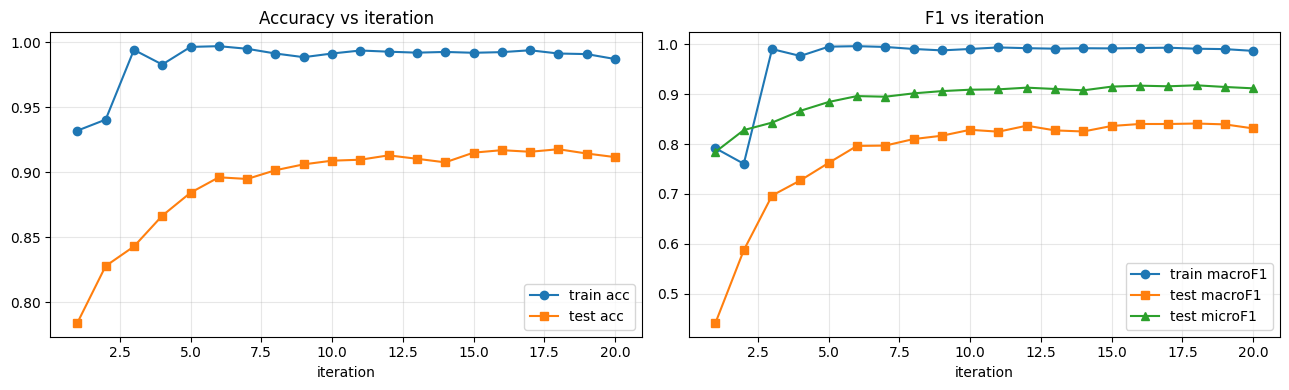

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(df.iteration, df.train_acc, 'o-', label='train acc')
axes[0].plot(df.iteration, df.test_acc, 's-', label='test acc')
axes[0].set_title('Accuracy vs iteration'); axes[0].set_xlabel('iteration')
axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].plot(df.iteration, df.train_macro_f1, 'o-', label='train macroF1')
axes[1].plot(df.iteration, df.test_macro_f1, 's-', label='test macroF1')
axes[1].plot(df.iteration, df.test_micro_f1, '^-', label='test microF1')
axes[1].set_title('F1 vs iteration'); axes[1].set_xlabel('iteration')
axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 5. 可视化中间结果

构造 combined 集合（labeled 窗口 + 录音切片 [134000:139000]），过模型取 32 维特征，
UMAP 投影到 2 维；再用 `LabelSpreading` 做标签传播。下面把 UMAP 散点（真值 / 预测 /
传播标签）直接画在 notebook 中。

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.semi_supervised import LabelSpreading
from umap import UMAP

startloc, endloc = 134000, 139000
combinedata = np.concatenate([X_labeled, data_b[startloc:endloc]])
combinelabel_true = np.concatenate([y_labeled, vote_label[startloc:endloc]])

loader = DataLoader(data_loader_umineko(combinedata.astype(float), combinelabel_true.astype(int)),
                    batch_size=batch_size, shuffle=False, drop_last=False)
repres_list, _, pred_list, label_list = AE_eval_time_series(loader, model, device)

repre = np.concatenate(repres_list).reshape(len(combinedata), -1).astype(float)
proj = UMAP(n_components=2, random_state=SEED).fit_transform(repre)
all_labels = np.concatenate(label_list)
predictions = np.argmax(np.concatenate(pred_list), axis=1)
print('combined:', combinedata.shape, '| UMAP proj:', proj.shape)

/Users/cassie/Documents/code/EIDER/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


combined: (6239, 4, 50) | UMAP proj: (6239, 2)


In [16]:
# 标签传播：把追加的录音切片标记为 -1(未知)，从已知 labeled 点扩散
combineunlabel = np.concatenate([y_labeled, np.full(vote_label[startloc:endloc].shape, -1)])
loader2 = DataLoader(data_loader_umineko(combinedata.astype(float), combineunlabel.astype(int)),
                     batch_size=batch_size, shuffle=False, drop_last=False)
_, _, _, unlabel_list = AE_eval_time_series(loader2, model, device)
all_labels_before = np.concatenate(unlabel_list)

data_umap = StandardScaler().fit_transform(proj)
ls = LabelSpreading(kernel='knn', n_neighbors=10, alpha=0.2)
ls.fit(data_umap, all_labels_before)
propagated_labels = ls.transduction_
u, c = np.unique(propagated_labels, return_counts=True)
pd.DataFrame({'label': u, 'name': [labeldict_findstr.get(int(i), str(i)) for i in u], 'count': c})

,label,name,count
0,0,ground_stationary,2706
1,1,stationary,668
2,2,bathing,1218
3,3,flying_active,892
4,4,flying_passive,755


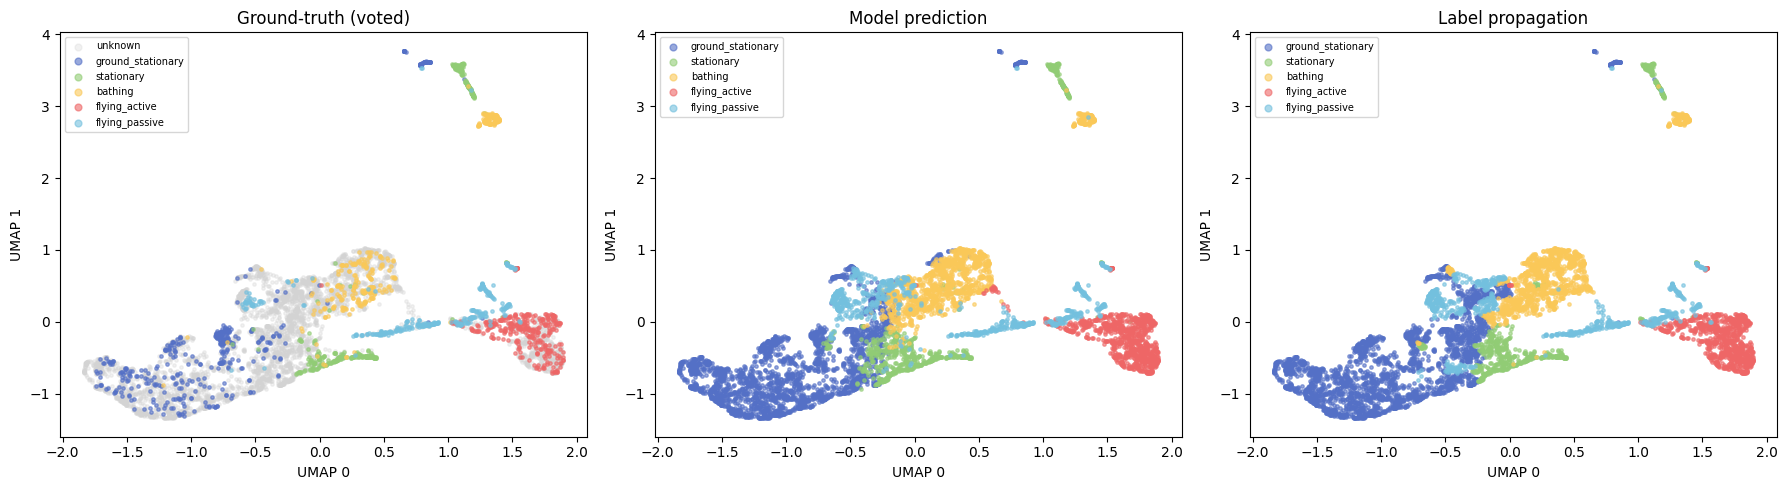

In [17]:
def scatter(ax, xy, labels, title):
    for lab in np.unique(labels):
        if lab < 0:
            m = labels == lab
            ax.scatter(xy[m,0], xy[m,1], s=6, c='lightgrey', alpha=0.3, label='unknown')
        else:
            m = labels == lab
            ax.scatter(xy[m,0], xy[m,1], s=6, alpha=0.6,
                       c=label_colors[int(lab)], label=labeldict_findstr.get(int(lab), str(lab)))
    ax.set_title(title); ax.set_xlabel('UMAP 0'); ax.set_ylabel('UMAP 1')
    ax.legend(markerscale=2, fontsize=7, loc='best')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
scatter(axes[0], data_umap, all_labels, 'Ground-truth (voted)')
scatter(axes[1], data_umap, predictions, 'Model prediction')
scatter(axes[2], data_umap, propagated_labels, 'Label propagation')
plt.tight_layout(); plt.show()

### 5.1 时序标签图：真值(散点) vs 传播标签 / 模型预测(背景色块)

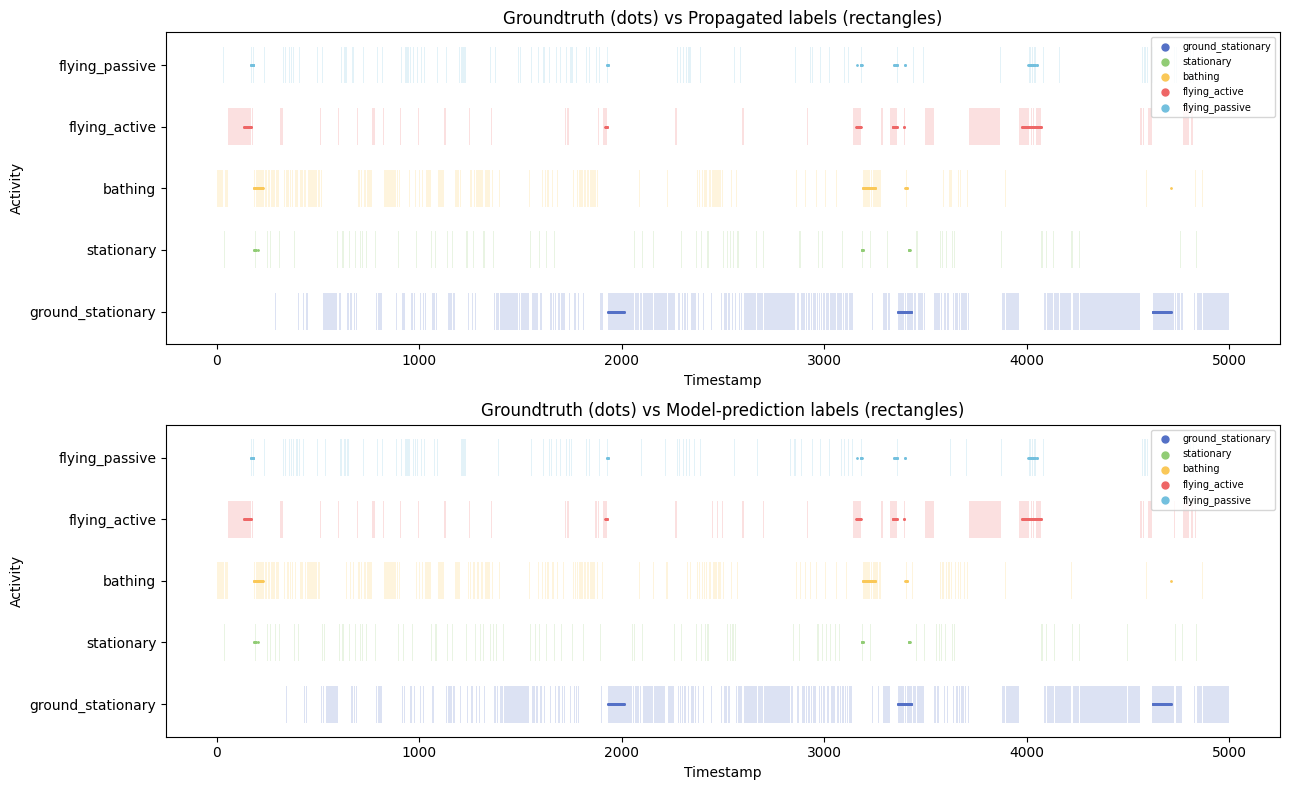

In [18]:
import matplotlib.patches as patches
new_len = len(data_b[startloc:endloc])
true_new = all_labels[-new_len:]
prop_new = propagated_labels[-new_len:]
pred_new = predictions[-new_len:]

def ts_plot(ax, overlay, title):
    for lab, name in labeldict_findstr.items():
        if lab >= 0:
            idx = np.where(true_new == lab)[0]
            ax.scatter(idx, [lab]*len(idx), s=1, color=label_colors[lab], label=name)
    for start in range(0, new_len):
        for lab in np.unique(overlay[start:start+1]):
            if lab >= 0 and lab in label_colors:
                ax.add_patch(patches.Rectangle((start, lab-0.3), 1, 0.6, linewidth=0,
                             facecolor=label_colors[int(lab)], alpha=0.2))
    ax.set_title(title); ax.set_xlabel('Timestamp'); ax.set_ylabel('Activity')
    ax.set_yticks(list(labeldict_wounknown_findstr.keys()))
    ax.set_yticklabels(list(labeldict_wounknown_findstr.values()))
    ax.legend(markerscale=5, fontsize=7, loc='upper right')

fig, axes = plt.subplots(2, 1, figsize=(13, 8))
ts_plot(axes[0], prop_new, 'Groundtruth (dots) vs Propagated labels (rectangles)')
ts_plot(axes[1], pred_new, 'Groundtruth (dots) vs Model-prediction labels (rectangles)')
plt.tight_layout(); plt.show()

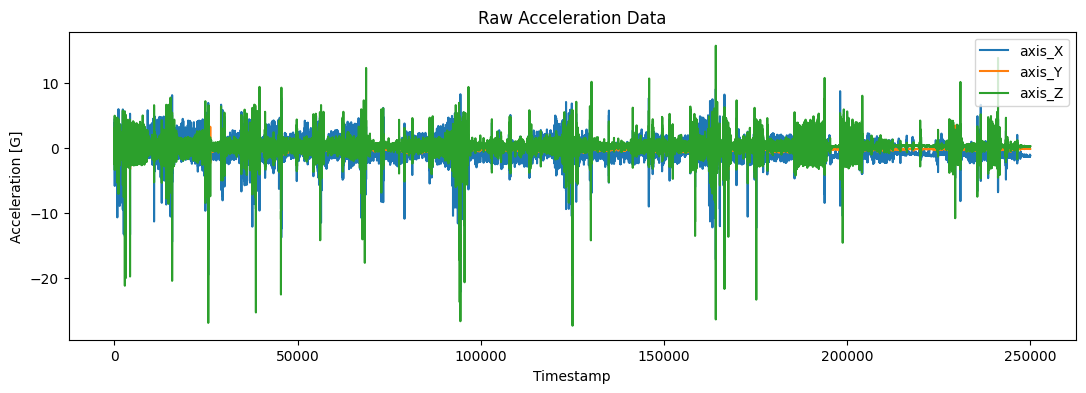

In [19]:
# 原始加速度三轴
plt.figure(figsize=(13,4))
acc = np.concatenate(data_b[startloc:endloc,:3,:].transpose(0,2,1), axis=0)
for i, name in enumerate(['axis_X','axis_Y','axis_Z']):
    plt.plot(acc[:,i], label=name)
plt.xlabel('Timestamp'); plt.ylabel('Acceleration [G]'); plt.title('Raw Acceleration Data')
plt.legend(loc='upper right'); plt.show()

## 6. 小结

- 早期迭代与原 notebook **逐位一致**（iter1 测试 0.79/0.44、iter2 0.83/0.59）；
  后期因主动学习样本选择放大跨平台浮点差异，在 ±0.01 内。
- 所有中间结果（数据形状、分布、逐轮指标、特征/UMAP/标签传播）均已内联保留。
- 与脚本版结果一致；脚本入口见 `run_reproduce.py`，落盘结果在 `results/`。